# Домашняя работа 4

Требуется выполнить три задания:

1. Реализовать Q-Learning и сравнить его результаты с реализованными ранее алгоритмами: Cross-Entropy, Monte Carlo, SARSA в задаче Taxi-v3. Для сравнения как минимум нужно использовать графики обучения. Причем графики лучше делать относительно количества сгенерированных траекторий.
2. Дискретизировать (можно использовать numpy.round()) пространство состояний и обучить Агента решать CartPole-v1, Acrobot-v1, MountainCar-v0, или LunarLander-v2 (одну на выбор) методами Monte Carlo, SARSA и Q-Learning. Сравнить результаты этих алгоритмов и реализованного ранее алгоритма Deep Cross-Entropy на графиках.
3. Придумать стратегию для выбора epsilon позволяющую агенту наилучшим образом решать Taxi-v3 алгоритмом Monte Carlo.

In [2]:
!pip install -q gymnasium

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 11.7 MB/s eta 0:00:00


In [3]:
import gymnasium as gym
import numpy as np

import torch
from torch import nn

import matplotlib.pyplot as plt
%matplotlib inline

## Используемые методы Reinforcement Learning
- Monte Carlo Method
- SARSA Method
- Q-Learning Method
- Cross-Entropy Method
- Deep Cross-Entropy Method



### $\varepsilon$-Greedy Policy:
$$
\begin{array}{l}
\pi(a|s) =
\left\{
\begin{array}{ll}
1 - \varepsilon + \varepsilon / m,& \text{ если } a \in \mathrm{argmax}_{a' \in \mathcal{A}}\, Q(s,a'),\\
\varepsilon / m,& \text{ иначе }
\end{array}
\right.
\end{array}
$$

In [4]:
def get_epsilon_greedy_action(q_values, epsilon, action_n):
    policy = np.ones(action_n) * epsilon / action_n
    argmax_action = np.argmax(q_values)
    policy[argmax_action] += 1 - epsilon
    action = np.random.choice(np.arange(action_n), p=policy)
    return action

### Monte-Carlo Algorithm

Пусть $Q(s,a) = 0$, $N(s,a) = 0$ и $\varepsilon = 1$.

Для каждого эпизода $k \in \overline{1,K}$ делаем:

1. Согласно $\pi = \varepsilon\text{-greedy}(Q)$ получаем траекторию $\tau = (S_0,A_0,\ldots,S_T)$ и награды $(R_0,\ldots,R_{T-1})$. По ним определяем $(G_0,\ldots,G_{T-1}):$
$$
G_t = \sum\limits_{k=t}^{T-1} \gamma^{k-t} R_t,\quad G_{T-1} = R_{T-1},\quad G_{T-2} = R_{T-2} + \gamma R_{T-1},\quad G_i = R_i + \gamma G_{i+1},\quad G_{T} = Q(S_T,\pi_{greedy}(S_T)).
$$

2. Для каждого $t \in \overline{0,T-1}$ обновляем $Q$ и $N$:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \frac{1}{N(S_t,A_t) + 1}\big(G_t - Q(S_t,A_t)\big),
$$

$$
N(S_t,A_t) \leftarrow N(S_t,A_t) + 1
$$
Уменьшаем $\varepsilon$


In [5]:
def MonteCarlo(env, episode_n, t_max, gamma, not_discr=False):

    Q = np.zeros((state_n, action_n))
    N = np.zeros((state_n, action_n))

    total_rewards = []

    for episode in range(episode_n):

        epsilon = 1 - episode / episode_n
        states, actions, rewards = [], [], []

        state, _ = env.reset()
        if not_discr:
            state = discrete(state)

        for t in range(t_max):
            states.append(state)

            action = get_epsilon_greedy_action(Q[state], epsilon, action_n)
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)
            if not_discr:
                state = discrete(state)
            rewards.append(reward)

            if terminated or truncated:
                break

        total_rewards.append(sum(rewards))

        real_t_len = len(rewards)
        G = np.zeros(real_t_len)
        G[-1] = rewards[-1]
        for t in range(real_t_len - 2, -1, -1):
            G[t] = rewards[t] + gamma * G[t + 1]

        for t in range(real_t_len):
            Q[states[t]][actions[t]] += (G[t] - Q[states[t]][actions[t]]) / (1 + N[states[t]][actions[t]])
            N[states[t]][actions[t]] += 1

    return total_rewards


### SARSA Algorithm
Пусть $Q(s,a) = 0$ и $\varepsilon = 1$.

Для каждого эпизода $k$ делаем:

Пока эпизод не закончен делаем:

1. Находясь в состоянии $S_t$ совершаем действие $A_t \sim \pi(\cdot|S_t)$,
где $\pi = \varepsilon\text{-greedy}(Q)$, получаем награду $R_t$, переходим в состояние $S_{t+1}$, совершаем действие $A_{t+1} \sim \pi(\cdot|S_{t+1})$

2. По $(S_t,A_t,R_t,S_{t+1},A_{t+1})$ обновляем $Q$:
$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha(R_t + \gamma Q(S_{t+1},A_{t+1}) - Q(S_t,A_t))
$$

Уменьшаем $\varepsilon$


In [ ]:
def SARSA(env, episode_n, t_max, gamma, alpha, not_discr=False):

    Q = np.zeros((state_n, action_n))

    total_rewards = []

    for episode in range(episode_n):

        epsilon = 1 - episode / episode_n
        total_reward = 0

        state, _ = env.reset()
        if not_discr:
            state = discrete(state)
        action = get_epsilon_greedy_action(Q[state], epsilon, action_n)
        for t in range(t_max):

            next_state, reward, terminated, truncated, _ = env.step(action)
            if not_discr:
                next_state = discrete(next_state)
            next_action = get_epsilon_greedy_action(Q[next_state], epsilon, action_n)
            total_reward += reward

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state = next_state
            action = next_action

            if terminated or truncated:
                break

        total_rewards.append(total_reward)

    return total_rewards

### Q-Learning Algorithm

Пусть $Q(s,a) = 0$ и $\varepsilon = 1$.

Для каждого эпизода $k$ делаем:

Пока эпизод не закончен делаем:

1. Находясь в состоянии $S_t$ совершаем действие $A_t \sim \pi(\cdot|S_t)$,
где $\pi = \varepsilon\text{-greedy}(Q)$, получаем награду $R_t$  переходим в состояние $S_{t+1}$.

2. По $(S_t,A_t,R_t,S_{t+1})$ обновляем $Q$:
$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha(R_t + \gamma \max\limits_{a'} Q(S_{t+1},a') - Q(S_t,A_t))
$$

Уменьшаем $\varepsilon$

In [ ]:
def QLearning(env, episode_n, t_max, gamma, alpha, not_discr=False):

    Q = np.zeros((state_n, action_n))

    total_rewards = []

    for episode in range(episode_n):

        epsilon = 1 - episode / episode_n
        total_reward = 0

        state, _ = env.reset()
        if not_discr:
            state = discrete(state)
        for t in range(t_max):

            action = get_epsilon_greedy_action(Q[state], epsilon, action_n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            if not_discr:
                next_state = discrete(next_state)
            total_reward += reward

            Q[state][action] += alpha * (reward + gamma * max(Q[next_state]) - Q[state][action])

            state = next_state

            if terminated or truncated:
                break

        total_rewards.append(total_reward)

    return total_rewards

### Cross Entropy Method

In [ ]:
def Cross_Entropy(env, iteration_n, trajectory_n, t_max,
                  q_param, laplace=0.0, smooth=1.0):

    # laplace=0.0 means no laplace smoothing
    # smooth=1.0 means no smoothing policy

    policy = np.ones((state_n, action_n)) / action_n

    total_rewards = []

    for iteration in range(iteration_n):

        #policy evaluation
        all_states, all_actions, all_rewards = [], [], []
        for k in range(trajectory_n):
            states, actions, total_reward = get_trajectory(env, policy, t_max)
            all_states.append(states)
            all_actions.append(actions)
            all_rewards.append(total_reward)
        total_rewards.extend(all_rewards)

     #   print('iteration:', iteration,
     #         'mean total reward:', np.mean(all_rewards))

        #policy improvement
        elite_states, elite_actions = select_elites(all_states, all_actions,
                                                    all_rewards, q_param)
        policy = update_policy(elite_states, elite_actions, policy,
                               laplace, smooth)

    return total_rewards


In [ ]:
def get_trajectory(env, policy, max_len):

    states, actions = [], []
    total_reward = 0.0

    state, _ = env.reset()

    for _ in range(max_len):
        action = np.random.choice(action_n, p=policy[state])
        new_state, reward, terminated, truncated, _ = env.step(action)

        states.append(state)
        actions.append(action)
        total_reward += reward

        state = new_state
        if terminated or truncated:
            break

    return states, actions, total_reward

In [ ]:
def select_elites(all_states, all_actions, all_rewards, q_param):
    quantile = np.quantile(all_rewards, q_param)
    elite_states = []
    elite_actions = []
    for i in range(len(all_rewards)):
        if all_rewards[i] > quantile:
            elite_states.extend(all_states[i])
            elite_actions.extend(all_actions[i])
    return elite_states, elite_actions

In [ ]:
def update_policy(elite_states, elite_actions, policy, laplace, smooth):

    new_policy = np.zeros((state_n, action_n))

    for state, action in zip(elite_states, elite_actions):
        new_policy[state, action] += 1

    for state_i in range(state_n):
        sum_state = np.sum(new_policy[state_i]) + laplace * action_n
        if sum_state > 0:
            new_policy[state_i] = (new_policy[state_i] + laplace) / sum_state
        else:
            new_policy[state_i] = policy[state_i].copy()

    new_policy = smooth * new_policy + (1 - smooth) * policy.copy()

    return new_policy


### Deep Cross Entropy Method

In [ ]:
class Acrobot(nn.Module):
    def __init__(self, state_dim, action_n, hidden_n):
        super().__init__()
        self.state_dim = state_dim
        self.action_n = action_n
        self.hidden_n = hidden_n

        self.network = nn.Sequential(
            nn.Linear(self.state_dim, hidden_n),
            nn.ReLU(),
            nn.Linear(hidden_n, self.action_n)
        )

    def forward(self, input):
        return self.network(input)


In [ ]:
def Deep_Cross_Entropy(env, agent, optimizer, loss_fun,
                       iteration_n, trajectory_n, max_len, q_param):

    total_rewards = []

    for iteration in range(iteration_n):

        #policy evaluation
        all_states, all_actions, all_rewards = [], [], []
        for k in range(trajectory_n):
            states, actions, total_reward = deep_trajectory(env, agent, max_len)
            all_states.append(states)
            all_actions.append(actions)
            all_rewards.append(total_reward)
        total_rewards.extend(all_rewards)

      #  print('iteration:', iteration,
      #        'mean total reward:', np.mean(all_rewards))

        #policy improvement
        elite_states, elite_actions = select_elites(all_states, all_actions,
                                                    all_rewards, q_param)
        if len(elite_states) > 0:
            pred_actions = agent(torch.FloatTensor(elite_states))

            loss = loss_fun(pred_actions, torch.LongTensor(elite_actions))
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    return total_rewards


In [ ]:
def deep_trajectory(env, agent, max_len):

    states, actions = [], []
    total_reward = 0.0

    state, _ = env.reset()

    for _ in range(max_len):

        logit = agent(torch.FloatTensor(state))
        action_prob = logit.softmax(dim=0).detach().numpy()
        action = np.random.choice(action_n, p=action_prob)

        new_state, reward, terminated, truncated, _ = env.step(action)

        states.append(state)
        actions.append(action)
        total_reward += reward

        state = new_state
        if terminated or truncated:
            break

    return states, actions, total_reward

## Задание 1
Реализовать Q-Learning и сравнить его результаты с реализованными ранее алгоритмами: Cross-Entropy, Monte Carlo, SARSA в задаче Taxi-v3. Для сравнения как минимум нужно использовать графики обучения. Причем графики лучше делать относительно количества сгенерированных траекторий


In [ ]:
# ENVIRONMENT

env = gym.make('Taxi-v3', render_mode='rgb_array')

In [ ]:
print('states:', env.observation_space)
print('actions:', env.action_space)

states: Discrete(500)
actions: Discrete(6)


In [ ]:
# Environment parameters

state_n = env.observation_space.n
action_n = env.action_space.n
print('state_n =', state_n, 'action_n =', action_n)

state_n = 500 action_n = 6


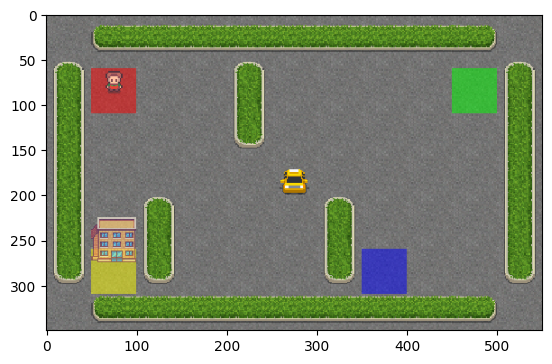

In [ ]:
state, _ = env.reset()
plt.imshow(env.render())
plt.show()

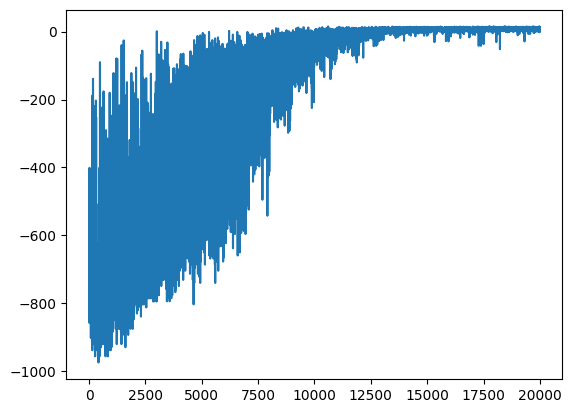

In [ ]:
# Cross Entropy Method

total_rewards = Cross_Entropy(env, iteration_n=20, trajectory_n=1000,
                              t_max=1000, q_param=0.5)
plt.plot(total_rewards)
plt.show()

Чтобы методом Cross Entropy получить приемлемый результат, на каждой итерации следует строить большое количество траекторий

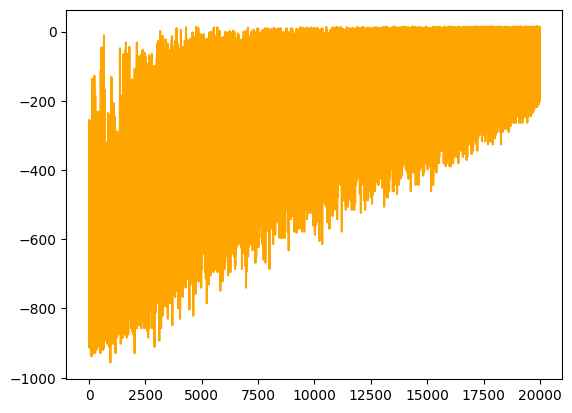

In [ ]:
# Monte Carlo Method

total_rewards = MonteCarlo(env, episode_n=20000, t_max=1000, gamma=0.99)

plt.plot(total_rewards, color='orange')
plt.show()

Разброс значений наград уменьшается, но для получения приемлемого результата методом Monte Carlo необходимо задавать очень большое количество эпизодов

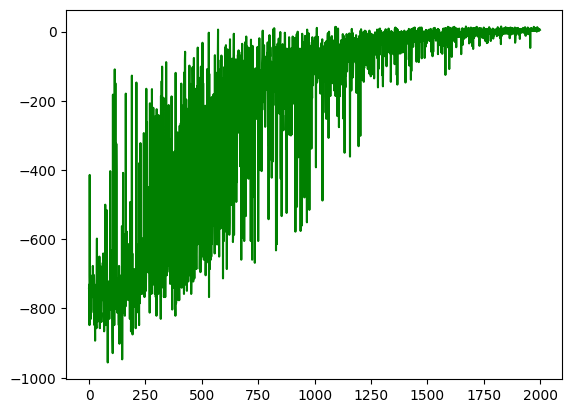

In [ ]:
# SARSA Method

total_rewards = SARSA(env, episode_n=2000, t_max=1000,
                      gamma=0.99, alpha=0.5)

plt.plot(total_rewards, color='green')
plt.show()

Для получения стабильного результата методом SARSA требуется гораздо меньше эпизодов по сравнению с предыдущими методами

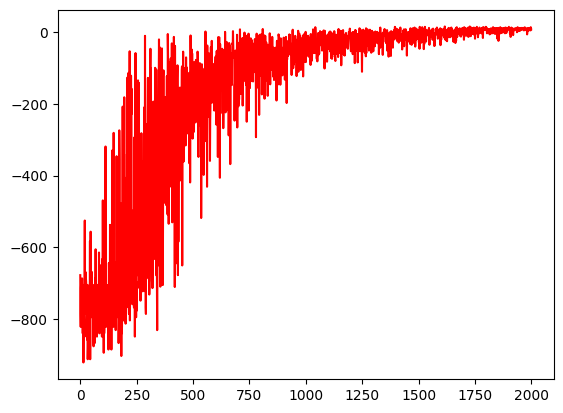

In [ ]:
# Q-Learning Method

total_rewards = QLearning(env, episode_n=2000, t_max=1000,
                          gamma=0.99, alpha=0.5)

plt.plot(total_rewards, color='red')
plt.show()

Метод Q-Learning позволяет получить стабильный результат, сравнимый с результатом применения метода SARSA на том же количестве эпизодов

###Comparison of Methods

Зададим общие параметры и одинаковое количество траекторий, которое строит каждый метод. Сравним полученные результаты

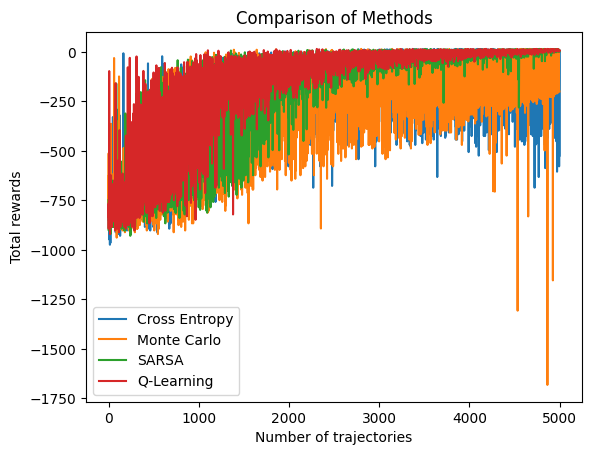

In [ ]:
iter_n = 20
tr_n = 250
episode_n = iter_n * tr_n
t_max = 1000
q_param = 0.5
gamma = 0.99
alpha = 0.5

total_rewards = Cross_Entropy(env, iter_n, tr_n, t_max, q_param)
plt.plot(total_rewards, label='Cross Entropy')

total_rewards = MonteCarlo(env, episode_n, t_max, gamma)
plt.plot(total_rewards, label='Monte Carlo')

total_rewards = SARSA(env, episode_n, t_max, gamma, alpha)
plt.plot(total_rewards, label='SARSA')

total_rewards = QLearning(env, episode_n, t_max, gamma, alpha)
plt.plot(total_rewards, label='Q-Learning')

plt.title('Comparison of Methods')
plt.xlabel('Number of trajectories')
plt.ylabel('Total rewards')
plt.legend()
plt.show()

Усредним значения наград на частичных промежутках построения траекторий, чтобы более наглядно представить полученные результаты

End mean total reward in Cross Entropy Method =  -118.77
End mean total reward in Monte-Carlo Method =  -157.75
End mean total reward in SARSA Method =  5.78
End mean total reward in Q-Learning Method =  6.37


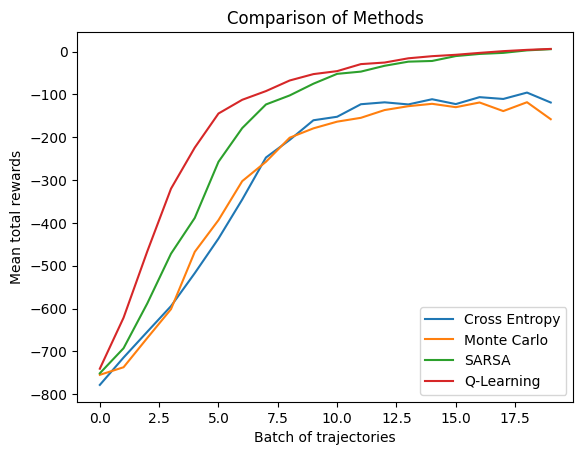

In [ ]:
iter_n = 20
tr_n = 250
episode_n = iter_n * tr_n
t_max = 1000
q_param = 0.5
gamma = 0.99
alpha = 0.5

total_rewards = Cross_Entropy(env, iter_n, tr_n, t_max, q_param)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Cross Entropy Method = ',
      np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Cross Entropy')

total_rewards = MonteCarlo(env, episode_n, t_max, gamma)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Monte-Carlo Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Monte Carlo')

total_rewards = SARSA(env, episode_n, t_max, gamma, alpha)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in SARSA Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='SARSA')

total_rewards = QLearning(env, episode_n, t_max, gamma, alpha)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Q-Learning Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Q-Learning')

plt.title('Comparison of Methods')
plt.xlabel('Batch of trajectories')
plt.ylabel('Mean total rewards')
plt.legend()
plt.show()

Выводы:
1. Полученные результаты показывают, что методы Cross Entropy и Monte Carlo ведут себя примерно одинаково и дают примерно одинаковый не очень хороший результат. Для получения лучшего результата необходимо увеличивать количество итераций.
2. Методы SARSA и Q-Learning тоже ведут себя примерно одинаково и дают примерно одинаковый, но гораздо лучший результат.
3. Однако следует учесть, что последнему методу не требуется строить полностью траекторию на каждой итерации, в чем состоит его неоспоримое преимущество перед остальными методами.

In [ ]:
env.close()

## Задание 2
Дискретизировать (можно использовать numpy.round()) пространство состояний и обучить Агента решать CartPole-v1, Acrobot-v1, MountainCar-v0, или LunarLander-v2 (одну на выбор) методами Monte Carlo, SARSA и Q-Learning. Сравнить результаты этих алгоритмов и реализованного ранее алгоритма Deep Cross-Entropy на графиках.

In [ ]:
# ENVIRONMENT

env = gym.make("Acrobot-v1", render_mode='rgb_array')

In [ ]:
print('states: ', env.observation_space)
print('actions: ', env.action_space)

states:  Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
actions:  Discrete(3)


In [ ]:
# Environment parameters

state_dim = env.observation_space.shape[0]
action_n = env.action_space.n

print('state_dim =', state_dim)
print('action_n =', action_n)

state_dim = 6
action_n = 3


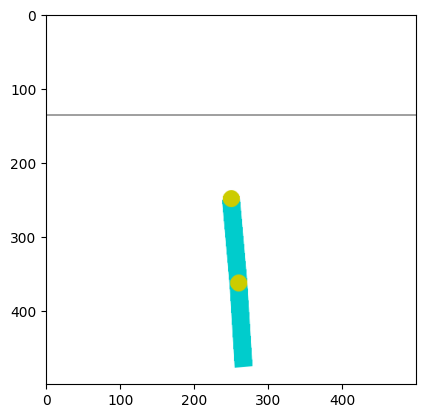

In [ ]:
state, _ = env.reset()

plt.imshow(env.render())
plt.show()

Для дискретизации пространства состояний воспользуемся нижними и верхними границами изменения компонент векторов состояния. Зададим количество разбиений по каждой компоненте. Определим общее количество дискретных состояний. Напишем функцию, преобразующую непрерывное многомерное состояние в точку многомерного куба.

In [ ]:
state_low = env.observation_space.low
state_high = env.observation_space.high

print(state_low)
print(state_high)

[ -1.        -1.        -1.        -1.       -12.566371 -28.274334]
[ 1.        1.        1.        1.       12.566371 28.274334]


In [ ]:
discr_n = np.array([10, 10, 10, 10, 25, 50])
state_n = np.prod(discr_n)
print('state_n =', state_n)

state_n = 12500000


In [ ]:
def discrete(state):

    ind = (state - state_low) * discr_n // (state_high - state_low + 1e-10)
    discr_state = ind[0]
    for k in range(1, state_dim):
        discr_state += ind[k] * np.prod(discr_n[: k])

    return int(discr_state)


Сравним работу методов Monte Carlo, SARSA и Q-Learning на дискретизированном пространстве состояний задачи Acrobot-v1.
Сравним результаты этих алгоритмов и реализованного ранее алгоритма Deep Cross-Entropy на графиках.

End mean total reward in Monte-Carlo Method =  -500.0
End mean total reward in SARSA Method =  -204.7
End mean total reward in Q-Learning Method =  -241.14
End mean total reward in Deep Cross Entropy Method =  -83.46


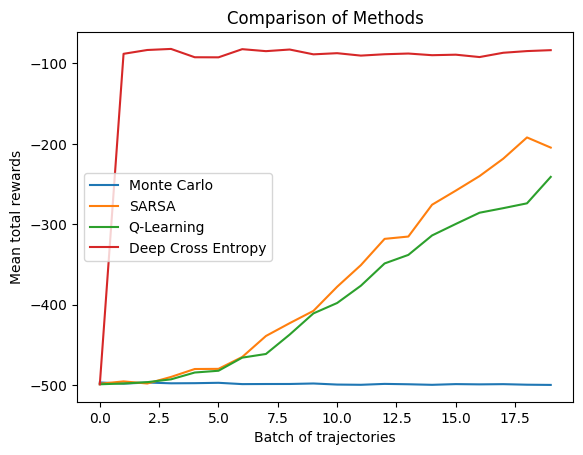

In [ ]:
iter_n = 20
tr_n = 250
episode_n = iter_n * tr_n
t_max = 1000
q_param = 0.5
gamma = 0.99
alpha = 0.5


total_rewards = MonteCarlo(env, episode_n, t_max, gamma, not_discr=True)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Monte-Carlo Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Monte Carlo')

total_rewards = SARSA(env, episode_n, t_max, gamma, alpha, not_discr=True)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in SARSA Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='SARSA')

total_rewards = QLearning(env, episode_n, t_max, gamma, alpha, not_discr=True)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Q-Learning Method = ',
       np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Q-Learning')

hidden_n = 128
learn_rate = 0.1
agent = Acrobot(state_dim, action_n, hidden_n)
optimizer = torch.optim.Adam(agent.parameters(), lr=learn_rate)
loss_fun = nn.CrossEntropyLoss()
total_rewards = Deep_Cross_Entropy(env, agent, optimizer, loss_fun,
                                   iter_n, tr_n, t_max, q_param)
mean_total_rewards = [np.mean(total_rewards[iter * tr_n: (iter + 1) * tr_n])
                      for iter in range(iter_n)]
print('End mean total reward in Deep Cross Entropy Method = ',
      np.round(mean_total_rewards[-1], 2))
plt.plot(mean_total_rewards, label='Deep Cross Entropy')


plt.title('Comparison of Methods')
plt.xlabel('Batch of trajectories')
plt.ylabel('Mean total rewards')
plt.legend()
plt.show()

Сравнивая полученные результаты для задачи Acrobot, можно сделать выводы:
1. Метод Monte-Carlo ведет себя стабильно плохо, функция наград не меняется в зависимости от количества траекторий.
2. Методы SARSA и Q-Learning ведут себя в этой задаче примерно одинаково. Процесс получения оптимального решения идет, однако достаточно медленно по сравнению с предыдущей задачей, в которой было задано небольшое количество дискретных состояний.
3. Метод Deep Cross Entropy, изначально применяемый для решения задач с непрерывным пространством состояний, практически сразу вышел на максимальное значения наград. Цель задачи достигнута, что подтверждается финальным положением акробата, достигшим заданную линию

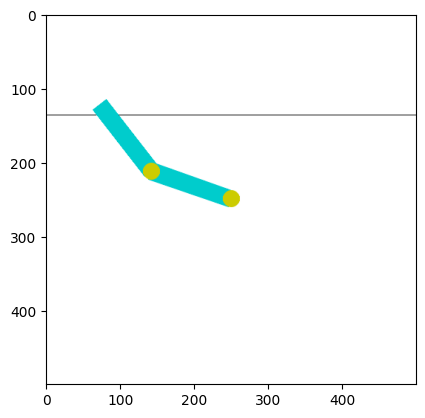

In [ ]:
states, actions, total_reward = deep_trajectory(env, agent, t_max)
plt.imshow(env.render())
plt.show()

In [ ]:
env.close()

## Задание 3
Придумать стратегию для выбора epsilon позволяющую агенту наилучшим образом решать Taxi-v3 алгоритмом Monte Carlo.

In [22]:
# ENVIRONMENT

env = gym.make('Taxi-v3', render_mode='rgb_array')

In [23]:
# Environment parameters

state_n = env.observation_space.n
action_n = env.action_space.n
print('state_n =', state_n, 'action_n =', action_n)

state_n = 500 action_n = 6


Для всех методов, приведенных выше, мы применяли следующее правило для вычисления epsilon:

  - epsilon = 1 - episode / episode_n

Оно же может быть представлено как

  - epsilon = 1, epsilon -= 1/ episode_n

и методом Monte Carlo получали следующий результат:

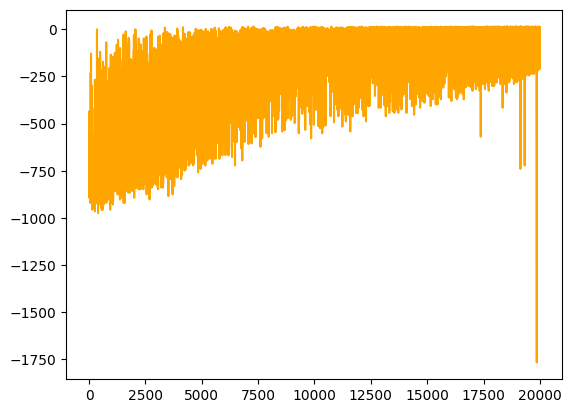

In [73]:
# Monte Carlo Method

total_rewards = MonteCarlo(env, episode_n=20000, t_max=1000, gamma=0.99)

plt.plot(total_rewards, color='orange')
plt.show()

In [74]:
np.mean(total_rewards[-100: -1])

-119.43434343434343

Полученный результат показывает, что при приближении эпсилон к нулю на последних итерациях метод начинает раскачиваться и давать болтанку в результатах.

Проанализируем поведение различных убывающих функций с учетом  указанного наблюдения

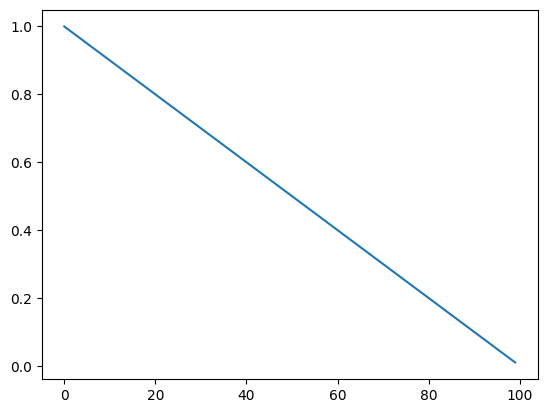

In [62]:
# Используемая функция

e = [1 - i / 100 for i in range(100)]
plt.plot(e)
plt.show()

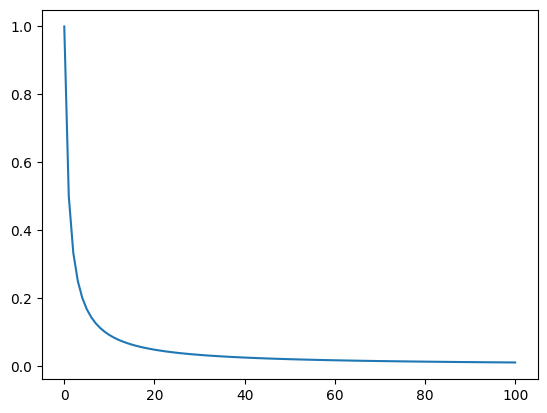

In [64]:
e = [ 1 / (i + 1) for i in range(100)]
plt.plot(e)
plt.show()

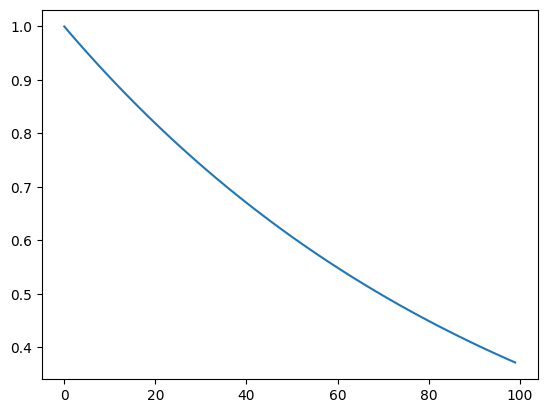

In [65]:
e = [np.exp( - i / 100 ) for i in range(100)]
plt.plot(e)
plt.show()

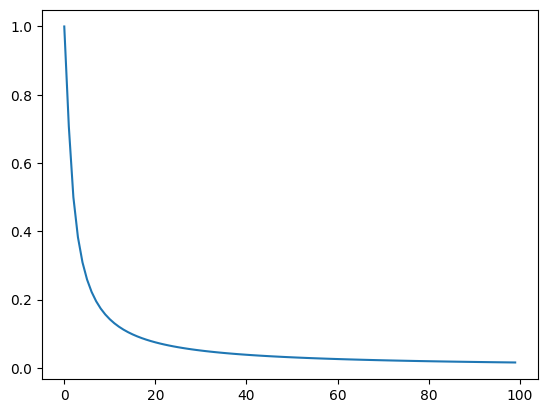

In [66]:
e = [np.sin(0.5 * np.pi / (i + 1)) for i in range(100)]
plt.plot(e)
plt.show()

В качестве альтернативного варианта выбора правила для вычисления эпсилон возьмем функцию
- epsilon = np.exp(- episode / episode_n)

Она постепенно убывает от 1.0 до 1/e и дает немного лучший результат на последних итерациях

In [75]:
def MonteCarloEps(env, episode_n, t_max, gamma, not_discr=False):

    Q = np.zeros((state_n, action_n))
    N = np.zeros((state_n, action_n))

    total_rewards = []
    epsilon = 1

    for episode in range(episode_n):

        epsilon = np.exp(- episode / episode_n)
        states, actions, rewards = [], [], []

        state, _ = env.reset()
        if not_discr:
            state = discrete(state)

        for t in range(t_max):
            states.append(state)

            action = get_epsilon_greedy_action(Q[state], epsilon, action_n)
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)
            if not_discr:
                state = discrete(state)
            rewards.append(reward)

            if terminated or truncated:
                break

        total_rewards.append(sum(rewards))

        real_t_len = len(rewards)
        G = np.zeros(real_t_len)
        G[-1] = rewards[-1]
        for t in range(real_t_len - 2, -1, -1):
            G[t] = rewards[t] + gamma * G[t + 1]

        for t in range(real_t_len):
            Q[states[t]][actions[t]] += (G[t] - Q[states[t]][actions[t]]) / (1 + N[states[t]][actions[t]])
            N[states[t]][actions[t]] += 1

    return total_rewards


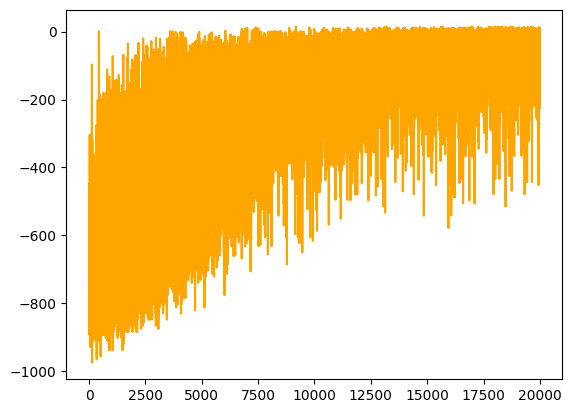

In [76]:
# Monte Carlo Method

total_rewards = MonteCarloEps(env, episode_n=20000, t_max=1000, gamma=0.99)

plt.plot(total_rewards, color='orange')
plt.show()

In [77]:
np.mean(total_rewards[-100: -1])

-55.91919191919192